# R2：PyTorch 二分类与 BCE

目标：使用 PyTorch 完成一个二分类训练流程，理解 logit、sigmoid、`BCEWithLogitsLoss` 与分类阈值的关系。

## 本节的关键对应

模型先计算线性输出：

$$
z=w^Tx+b
$$

这里的 `z` 叫 **logit**，它不是概率。评估时才将它转换为概率：

$$
p=\sigma(z)
$$

PyTorch 的 `BCEWithLogitsLoss` 已经把 sigmoid 和二元交叉熵合在一起，并且数值更稳定。因此训练时不要先手动 sigmoid 再把结果交给它。

In [1]:
import copy

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

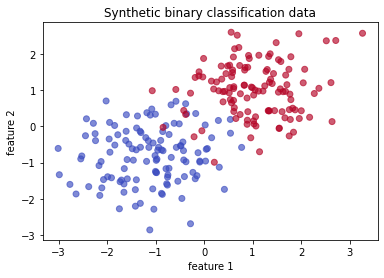

In [2]:
# 构造两类有少量重叠的二维数据。0 类在左下，1 类在右上。
class_0 = torch.randn(120, 2) * 0.8 + torch.tensor([-1.0, -1.0])
class_1 = torch.randn(120, 2) * 0.8 + torch.tensor([1.0, 1.0])

X_all = torch.cat([class_0, class_1])
# BCE 的标签通常使用 float，且形状与模型输出一致，都是 (样本数, 1)。
y_all = torch.cat([torch.zeros(120, 1), torch.ones(120, 1)])

indices = torch.randperm(len(X_all))
train_indices, val_indices = indices[:192], indices[192:]
X_train, y_train = X_all[train_indices], y_all[train_indices]
X_val, y_val = X_all[val_indices], y_all[val_indices]

plt.scatter(X_all[:, 0], X_all[:, 1], c=y_all.squeeze(), cmap='coolwarm', alpha=0.65)
plt.title('Synthetic binary classification data')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

In [3]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

# 两个输入特征，输出一个 logit；这里不要在模型末尾加入 Sigmoid。
model = nn.Linear(2, 1)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [4]:
def evaluate_binary_model(model, data_loader):
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            all_logits.append(model(batch_X))
            all_labels.append(batch_y)

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()

    return labels, probabilities, predictions

In [5]:
epochs = 100
train_loss_history = []
val_loss_history = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(epochs):
    model.train()
    train_total_loss = 0.0
    train_total_samples = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)             # 输出 logit，不是概率。
        loss = loss_function(logits, batch_y)  # BCEWithLogitsLoss 内部会处理 sigmoid。
        loss.backward()
        optimizer.step()

        train_total_loss += loss.item() * len(batch_X)
        train_total_samples += len(batch_X)

    model.eval()
    val_total_loss = 0.0
    val_total_samples = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_logits = model(batch_X)
            val_loss = loss_function(val_logits, batch_y)
            val_total_loss += val_loss.item() * len(batch_X)
            val_total_samples += len(batch_X)

    train_epoch_loss = train_total_loss / train_total_samples
    val_epoch_loss = val_total_loss / val_total_samples
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)
print(f'best validation BCE: {best_val_loss:.4f}')

best validation BCE: 0.1530


validation accuracy: 0.896
validation ROC-AUC:  0.990


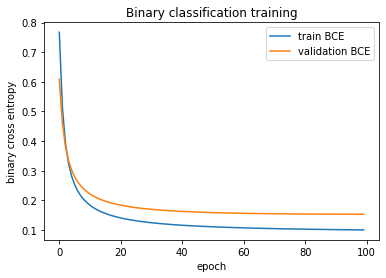

In [6]:
labels, probabilities, predictions = evaluate_binary_model(model, val_loader)

y_true = labels.numpy().ravel()
y_proba = probabilities.numpy().ravel()
y_pred = predictions.numpy().ravel()

print(f'validation accuracy: {accuracy_score(y_true, y_pred):.3f}')
print(f'validation ROC-AUC:  {roc_auc_score(y_true, y_proba):.3f}')

plt.plot(train_loss_history, label='train BCE')
plt.plot(val_loss_history, label='validation BCE')
plt.xlabel('epoch')
plt.ylabel('binary cross entropy')
plt.title('Binary classification training')
plt.legend()
plt.show()

## 本节结论

训练时将 logit 直接传给 `BCEWithLogitsLoss`；评估时才用 `torch.sigmoid(logit)` 获得概率，并按阈值转为 0/1 预测。下一节会增加隐藏层和 ReLU，把线性分类器升级为真正的多层神经网络。